In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
! pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [191]:
! pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
data_dir=r"C:\Users\daran\Downloads\ec4aeca2a8032be0347eb12ca3d29c96\cleaned"
raw_dir=r"C:\Users\daran\Downloads\ec4aeca2a8032be0347eb12ca3d29c96"

In [194]:
customers = pd.read_csv(f"{data_dir}\\customers_clean.csv")
billing = pd.read_csv(f"{data_dir}\\billing_clean.csv")
payments = pd.read_csv(f"{data_dir}\\payments_clean.csv")
subscriptions = pd.read_csv(f"{data_dir}\\subscriptions_clean.csv")
usage_data = pd.read_csv(f"{data_dir}\\usage_data_clean.csv")

complaints = pd.read_csv(f"{raw_dir}\\complaints.csv")
network_quality = pd.read_csv(f"{raw_dir}\\network_quality.csv")
states = pd.read_csv(f"{raw_dir}\\states.csv")
retention_campaigns = pd.read_csv(f"{raw_dir}\\retention_campaigns.csv")


In [195]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)
print("ok loaded")

ok loaded


In [196]:
#%%overall counts
status_count=customers["customer_status"].value_counts()
print(status_count)

customer_status
Active     15494
Churned     3506
Name: count, dtype: int64


In [197]:
churned_rate=(customers['customer_status'] == 'Churned').mean() * 100
print(churned_rate)

18.45263157894737


In [198]:
print(f"Active: {status_count.get('Active', 0)}")

Active: 15494


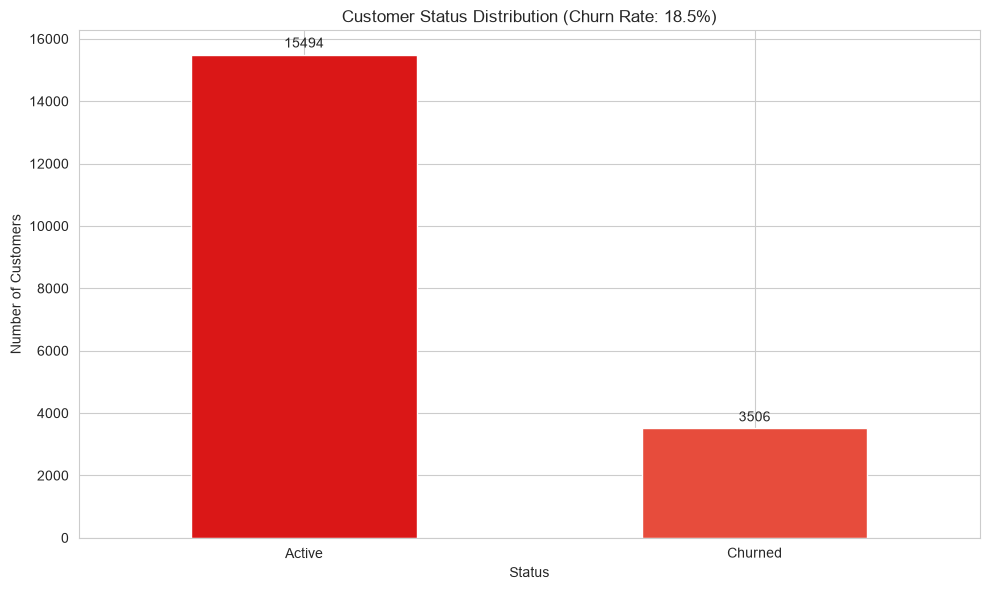

In [199]:
#  Chart 1: Overall churn rate (with value labels on bars)
fig, ax = plt.subplots()

bars = status_count.plot(kind='bar', ax=ax, color=["#da1717", '#e74c3c'])

# Add the value label on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

ax.set_title(f'Customer Status Distribution (Churn Rate: {churned_rate:.1f}%)')
ax.set_xlabel('Status')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_overall_churn.png', dpi=150)
plt.show()

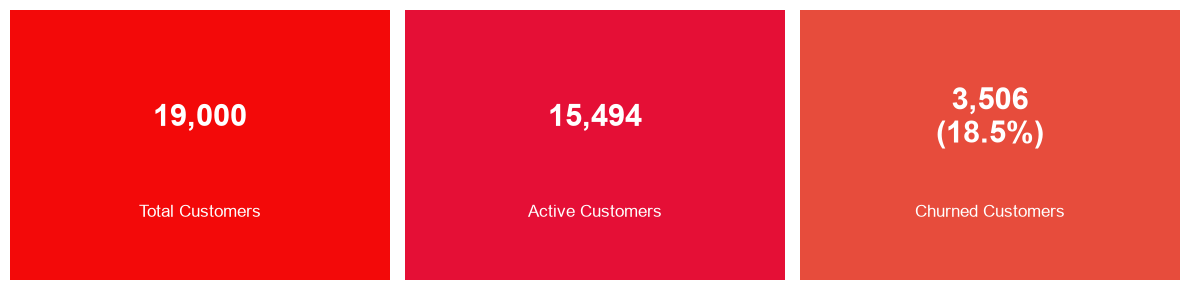

In [200]:
# Chart 1: Visual KPI Cards
total_customers = len(customers)
active_count = (customers['customer_status'] == 'Active').sum()
churned_count = (customers['customer_status'] == 'Churned').sum()
churned_rate = (customers['customer_status'] == 'Churned').mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

kpi_data = [
    ("Total Customers", f"{total_customers:,}", "#f30909"),
    ("Active Customers", f"{active_count:,}", "#e50f36"),
    ("Churned Customers", f"{churned_count:,}\n({churned_rate:.1f}%)", "#e74c3c"),
]

for ax, (label, value, color) in zip(axes, kpi_data):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=22, fontweight='bold', color='white')
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=12, color='white')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('chart1_kpi_cards.png', dpi=150)
plt.show()

Of the 19,000 total customers, 15,494 (81.5%) remain active while 3,506 (18.5%) have churned. This gives a baseline churn rate of 18.5% against which all subsequent segment, tenure, and behavioral breakdowns in this analysis can be compared

In [201]:
#merging 2 tables
merged=customers.merge(subscriptions[['customer_id','billing_cycle']] ,on ='customer_id', how ='inner')
print(merged.shape)
merged[['customer_id', 'customer_status', 'billing_cycle']].head(10)

(20523, 29)


,customer_id,customer_status,billing_cycle
0,C0000001,Churned,Monthly
1,C0000002,Active,Monthly
2,C0000003,Churned,Annual
3,C0000004,Active,Annual
4,C0000004,Active,Monthly
5,C0000005,Churned,Monthly
6,C0000006,Active,Monthly
7,C0000007,Churned,Monthly
8,C0000008,Active,Annual
9,C0000009,Active,Monthly


In [202]:
#churn by billing cycle
churnbycycle=merged.groupby("billing_cycle")["customer_status"].apply(lambda x : (x =="Churned") .mean()*100)
print(churnbycycle)

billing_cycle
Annual      7.828656
Monthly    22.062620
Name: customer_status, dtype: float64


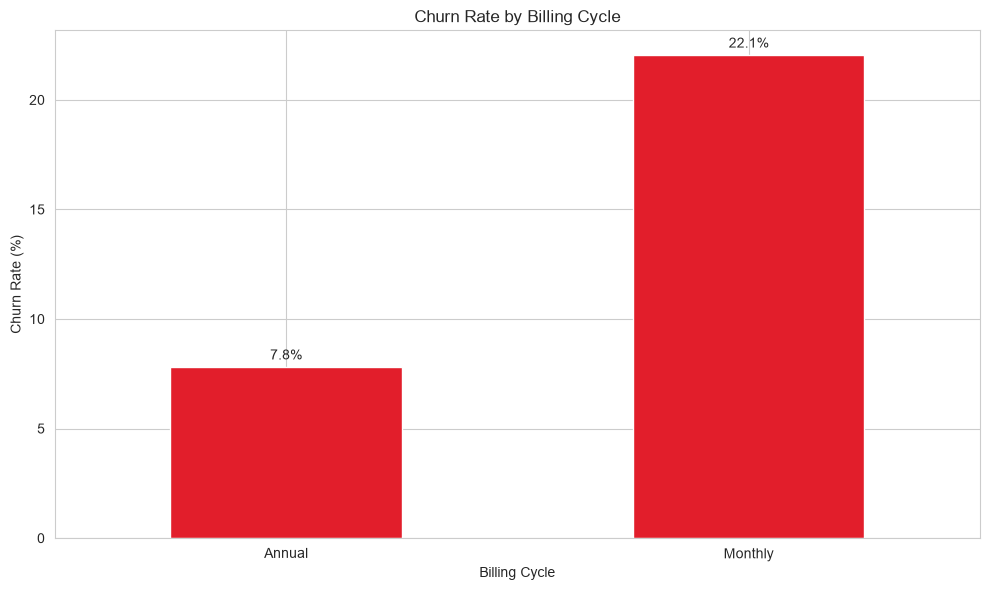

In [203]:
# Chart 2: Build the chart
fig, ax = plt.subplots()

bars = churnbycycle.plot(kind='bar', ax=ax, color="#e21e2b")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('Churn Rate by Billing Cycle')
ax.set_xlabel('Billing Cycle')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_churn_by_billing_cycle.png', dpi=150)
plt.show()

Monthly-cycle customers churn at 22.1%,
 nearly three times the rate of Annual-cycle customers at 7.8%. 
 This suggests billing cycle is a strong churn predictor — likely because annual plans create switching friction (upfront commitment, contract terms) that monthly plans lack. This makes billing_cycle a strong candidate variable for targeting retention efforts, prioritizing monthly subscribers for proactive outreach.

In [204]:
def get_tenure_band(months):
    if months <= 3:
        return "0-3m"
    elif months <= 12:
        return "3-12m"
    elif months <= 36:
        return "1-3y"
    else:
        return "3y+"

tenure_band
0-3m     74.899866
3-12m    52.282158
1-3y     36.177715
3y+       8.325578
Name: customer_status, dtype: float64


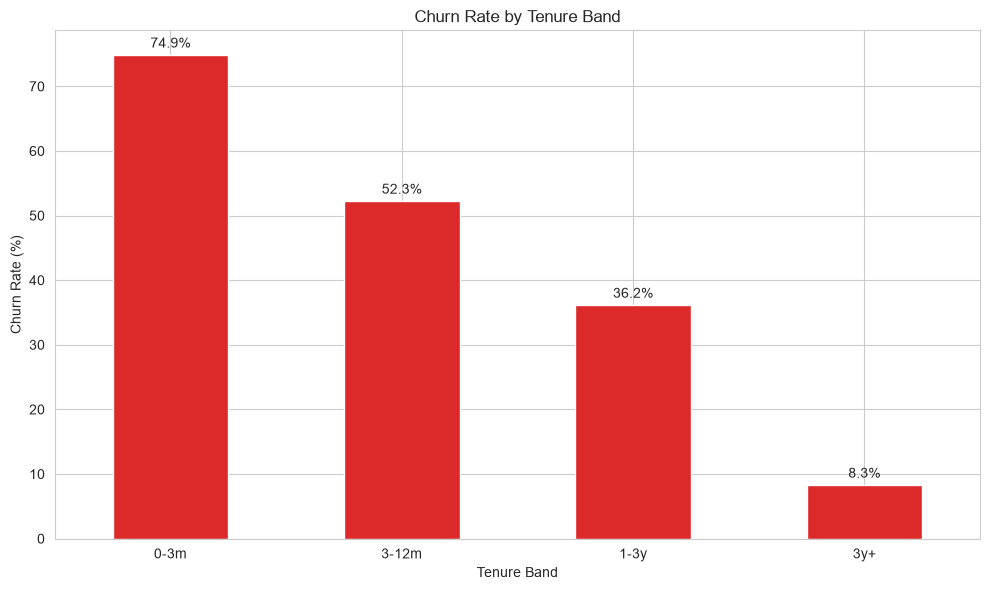

In [205]:
# churn by tenure
customers['tenure_band'] = customers['tenure_months'].apply(get_tenure_band)

band_order = ["0-3m", "3-12m", "1-3y", "3y+"]
churn_by_tenure = customers.groupby('tenure_band')['customer_status'].apply(
    lambda x: (x == 'Churned').mean() * 100
).reindex(band_order)

print(churn_by_tenure)

fig, ax = plt.subplots()
churn_by_tenure.plot(kind='bar', ax=ax, color="#dc2929")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('Churn Rate by Tenure Band')
ax.set_xlabel('Tenure Band')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_churn_by_tenure.png', dpi=150)
plt.show()

Churn rate declines sharply and consistently with tenure:
 customers in their first 3 months churn at 74.9%,
 dropping to 52.3% by 3-12 months,
 36.2% for 1-3 year customers,
 and just 8.3% for customers retained beyond 3 years. 
 
 This indicates the first few months are by far the highest-risk period for churn — likely reflecting onboarding friction, unmet expectations, or price sensitivity before customers become habituated to the service. This strongly suggests retention efforts should be front-loaded into the first 90 days of the customer lifecycle, where nearly three-quarters of new customers are currently being lost

In [206]:
# Churn by number of unresolved complaints 
unresolved_only = complaints[complaints['status'] == 'Unresolved']
complaint_counts = unresolved_only.groupby('customer_id').size()

print(complaint_counts.head(10))
print("\nTotal customers with at least 1 unresolved complaint:", len(complaint_counts))

customer_id
C0000001    1
C0000003    1
C0000005    2
C0000009    1
C0000010    1
C0000016    2
C0000017    1
C0000019    1
C0000027    1
C0000029    1
dtype: int64

Total customers with at least 1 unresolved complaint: 6058


In [207]:
# Attach complaint count to customers, filling missing with 0
customers['unresolved_complaints'] = customers['customer_id'].map(complaint_counts).fillna(0).astype(int)

print(customers[['customer_id', 'unresolved_complaints']].head(10))
print("\nDistribution:", customers['unresolved_complaints'].value_counts().sort_index())

  customer_id  unresolved_complaints
0    C0000001                      1
1    C0000002                      0
2    C0000003                      1
3    C0000004                      0
4    C0000005                      2
5    C0000006                      0
6    C0000007                      0
7    C0000008                      0
8    C0000009                      1
9    C0000010                      1

Distribution: unresolved_complaints
0    12942
1     4934
2      975
3      133
4       15
5        1
Name: count, dtype: int64


In [208]:
#  Bucket complaint counts
def get_complaint_bucket(count):
    if count == 0:
        return "0"
    elif count == 1:
        return "1"
    else:
        return "2+"

customers['complaint_bucket'] = customers['unresolved_complaints'].apply(get_complaint_bucket)
print(customers['complaint_bucket'].value_counts())

complaint_bucket
0     12942
1      4934
2+     1124
Name: count, dtype: int64


complaint_bucket
0     15.113584
1     23.368464
2+    35.320285
Name: customer_status, dtype: float64


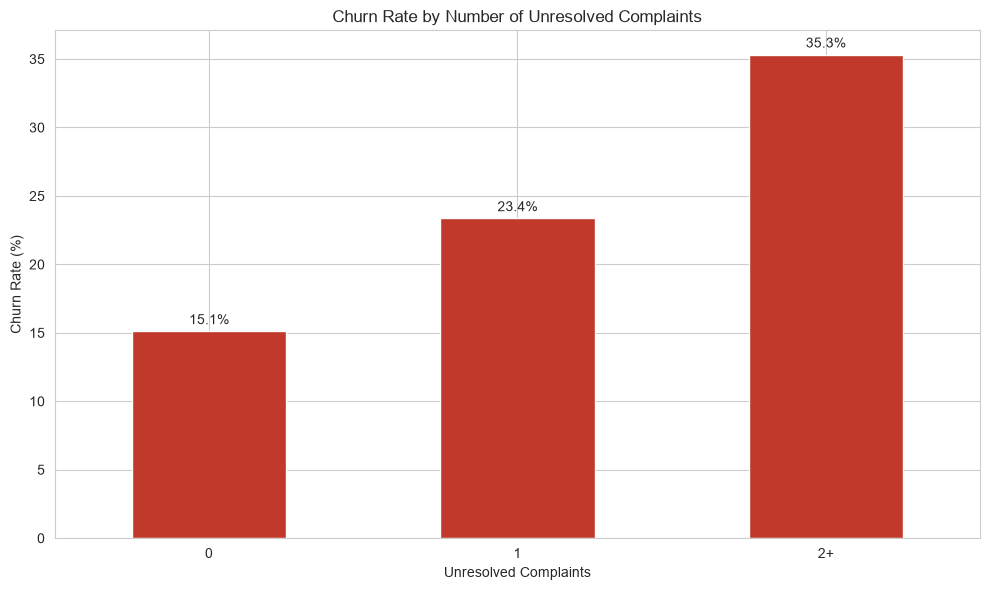

In [209]:
# # Churn rate by unresolved complaint bucket
bucket_order = ["0", "1", "2+"]

churn_by_complaints = customers.groupby('complaint_bucket')['customer_status'].apply(
    lambda x: (x == 'Churned').mean() * 100
).reindex(bucket_order)

print(churn_by_complaints)

fig, ax = plt.subplots()
churn_by_complaints.plot(kind='bar', ax=ax, color='#c0392b')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('Churn Rate by Number of Unresolved Complaints')
ax.set_xlabel('Unresolved Complaints')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_churn_by_complaints.png', dpi=150)
plt.show()

Churn rate rises sharply with unresolved complaint count:
 customers with 0 unresolved complaints churn at 15.1%, 
 nearly doubling to 23.4% with 1 unresolved complaint,
  and more than doubling again to 35.3% with 2 or more.
   This confirms unresolved complaints are a strong, consistent churn driver — complaint resolution speed and first-contact resolution rate should be treated as high-priority retention levers, especially for customers who have filed multiple unresolved complaints

In [210]:
##	Churn by customer segment — Mass / Value / Premium / Enterprise.
churn_by_customersegment = customers.groupby('customer_segment')['customer_status'].apply(
    lambda x: (x == 'Churned').mean() * 100
).sort_values(ascending=False)
print(churn_by_customersegment)


customer_segment
Mass          26.671214
Value         20.577792
Premium       15.126149
Enterprise    11.942446
Name: customer_status, dtype: float64


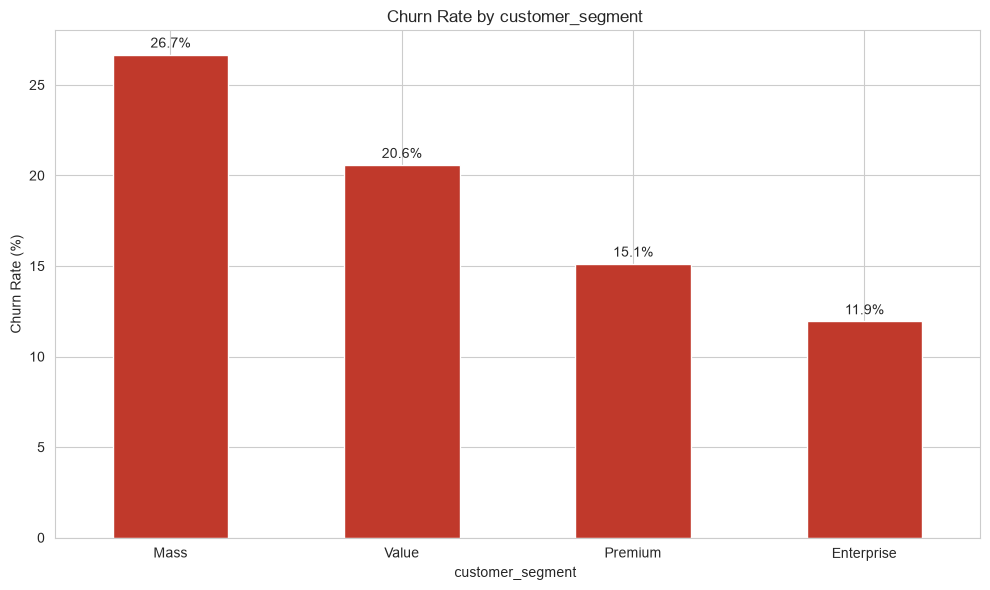

In [211]:
fig, ax = plt.subplots()
churn_by_customersegment .plot(kind='bar', ax=ax, color='#c0392b')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('Churn Rate by customer_segment ')
ax.set_xlabel('customer_segment ')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart5_churn_by_customer_segment .png', dpi=150)
plt.show()

Churn rate decreases steadily as customer segment moves upmarket: 
 Mass segment customers churn at 26.7%, the highest of any segment, 
 while Value (20.6%),
 Premium (15.1%), 
 and Enterprise (11.9%) show progressively lower churn. 
 This suggests higher-value segments are better retained — likely due to stronger service commitments, higher switching costs, or more dedicated account support — while Mass segment customers may need targeted retention investment given their higher volume and higher churn risk

In [212]:
##•	Top 10 states/circles by churned customers 

merged=customers.merge(states[['state_id','state_name']] ,on = 'state_id', how= "inner")
print(merged.shape)
merged[["customer_id","customer_status","state_name"]].head(10)

(19000, 32)


,customer_id,customer_status,state_name
0,C0000001,Churned,Chhattisgarh
1,C0000002,Active,Haryana
2,C0000003,Churned,Gujarat
3,C0000004,Active,Maharashtra
4,C0000005,Churned,Telangana
5,C0000006,Active,Mizoram
6,C0000007,Churned,Odisha
7,C0000008,Active,Andhra Pradesh
8,C0000009,Active,Chhattisgarh
9,C0000010,Churned,Karnataka


In [213]:

# # Chart 6: Top 10 states by churned customer count

# Filter down to ONLY churned customers first
churned_only = merged[merged['customer_status'] == 'Churned']


top10_states_by_churns = churned_only.groupby('state_name').size().sort_values(ascending=False).head(10)

print(top10_states_by_churns)

state_name
Maharashtra       305
Uttar Pradesh     285
Tamil Nadu        280
Rajasthan         244
Karnataka         222
Gujarat           191
Madhya Pradesh    182
Kerala            162
Andhra Pradesh    160
West Bengal       157
dtype: int64


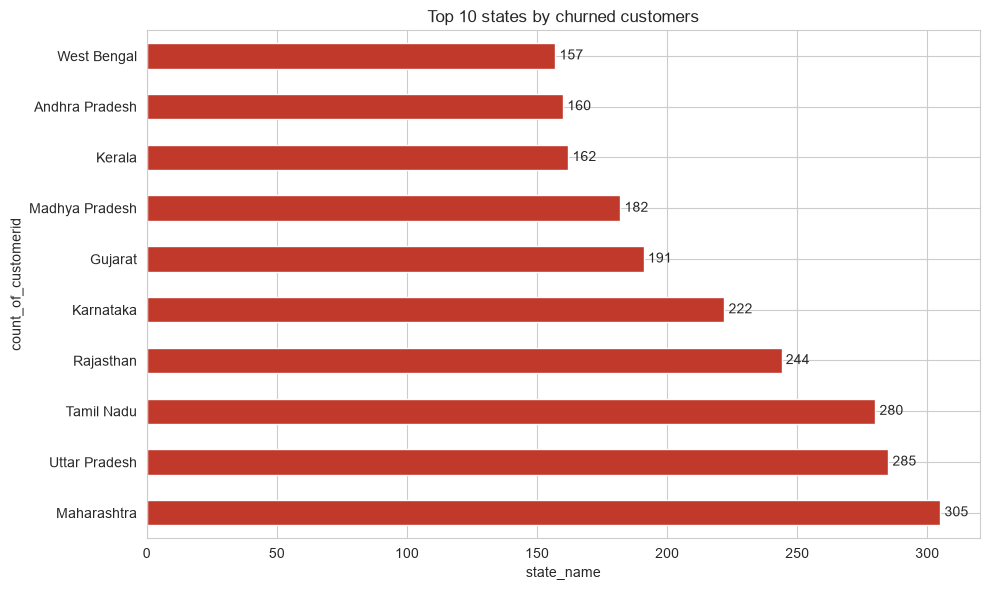

In [214]:
fig, ax = plt.subplots()
top10_states_by_churns.plot(kind='barh', ax=ax, color='#c0392b')

for container in ax.containers:
    ax.bar_label(container, padding=3)

ax.set_title('Top 10 states by churned customers')
ax.set_xlabel('state_name')
ax.set_ylabel('count_of_customerid')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart6_top10_states_by_churns.png', dpi=150)
plt.show()

Maharashtra leads in churned customer count (305), 
followed by Uttar Pradesh (285) 
and Tamil Nadu (280).
 These top 3 states account for a disproportionate share of total churn relative to the other 19 states/circles, suggesting regional factors — competitor presence, network quality, or regional pricing sensitivity — may be driving elevated churn in these specific markets

In [215]:
##•	Average data usage by city tier
merged=customers.merge(usage_data[['customer_id','data_gb_used']] ,on = 'customer_id', how= "inner")
print(merged.shape)
merged[["city_tier","customer_id","data_gb_used"]].head(10)


(57000, 32)


,city_tier,customer_id,data_gb_used
0,Tier-2,C0000001,22.35
1,Tier-2,C0000001,13.24
2,Tier-2,C0000001,13.09
3,Metro,C0000002,167.23
4,Metro,C0000002,109.72
5,Metro,C0000002,121.10
6,Tier-2,C0000003,8.33
7,Tier-2,C0000003,15.86
8,Tier-2,C0000003,62.36
9,Tier-2,C0000004,11.20


In [216]:
##Chart 7: Average data usage by city tier
avg_usage_by_tier = merged.groupby('city_tier')['data_gb_used'].mean().sort_values(ascending=False)

print(avg_usage_by_tier)

city_tier
Metro     36.010909
Tier-2    26.525301
Tier-3    18.375426
Name: data_gb_used, dtype: float64


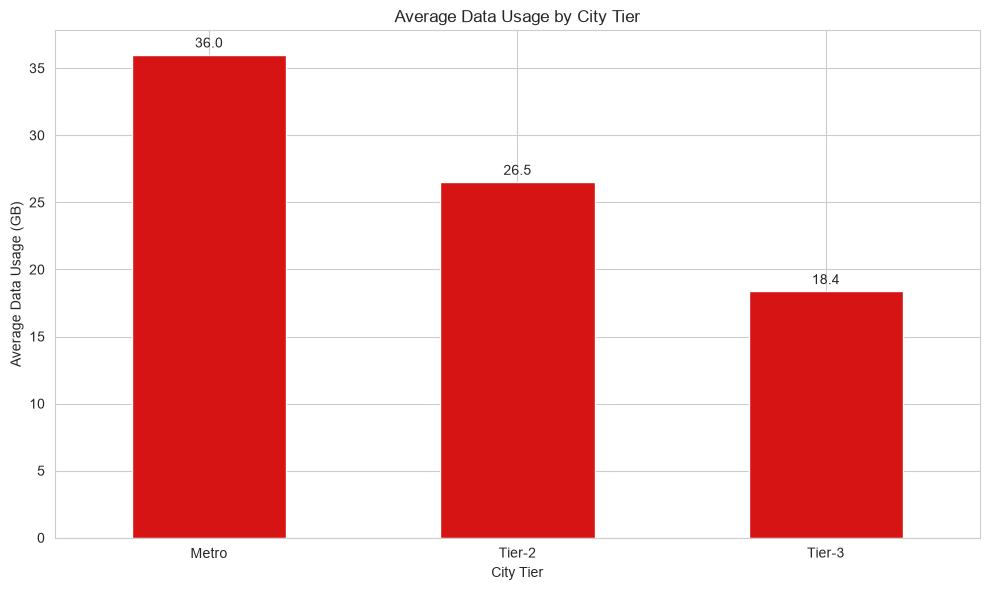

In [217]:

fig, ax = plt.subplots()
avg_usage_by_tier.plot(kind='bar', ax=ax, color="#d61414")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

ax.set_title('Average Data Usage by City Tier')
ax.set_xlabel('City Tier')
ax.set_ylabel('Average Data Usage (GB)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart7_usage_by_city_tier.png', dpi=150)
plt.show()

Average data usage decreases clearly by city tier: 
Metro customers use 36.0 GB/month on average, 
compared to 26.5 GB in Tier-2 
and 18.4 GB in Tier-3 — roughly double the Tier-3 rate. 
This likely reflects both greater network availability in metro areas and higher digital engagement among metro subscribers.

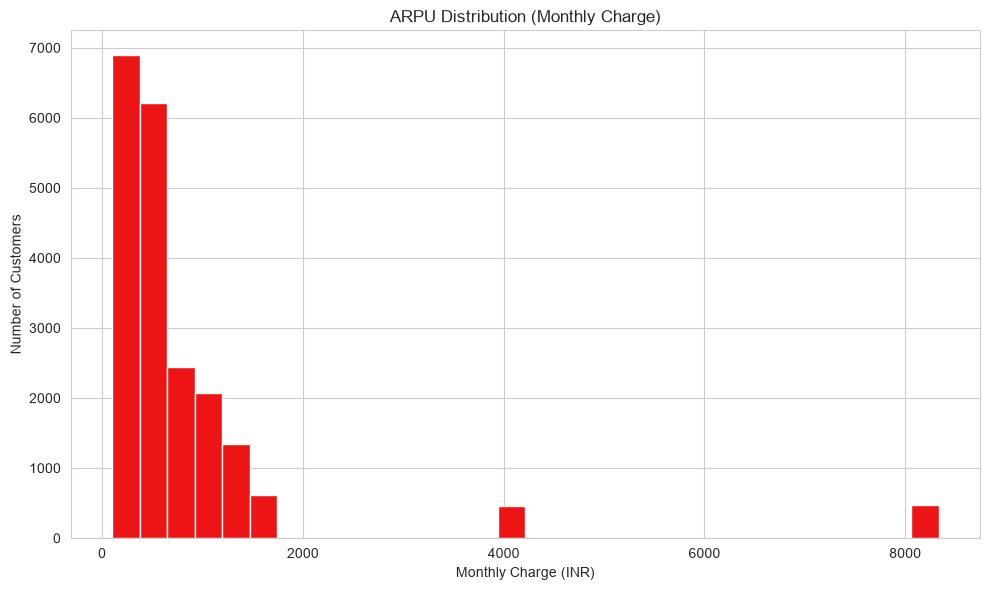

count    20523.000000
mean       842.256347
std       1317.933773
min         99.000000
25%        300.000000
50%        499.000000
75%        899.000000
max       8333.000000
Name: monthly_charge_inr, dtype: float64


In [218]:
##	ARPU distribution — a histogram of monthly charge across the base.
# Chart 8: ARPU distribution (histogram)
fig, ax = plt.subplots()
ax.hist(subscriptions['monthly_charge_inr'], bins=30, color="#ec1414", edgecolor='white')

ax.set_title('ARPU Distribution (Monthly Charge)')
ax.set_xlabel('Monthly Charge (INR)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart8_arpu_distribution.png', dpi=150)
plt.show()

print(subscriptions['monthly_charge_inr'].describe())

ARPU (monthly charge) is heavily right-skewed: 
the median customer pays ₹499/month, and 75% of customers pay ₹899 or less, but the distribution has a long tail extending to ₹8,333. 
The mean (₹842) sits well above the median (₹499), confirming that a small number of high-value (likely Enterprise/Premium) customers pull the average upward. 
This suggests average ARPU alone is a misleading metric for this business — segment-level ARPU (as shown in Chart 4) gives a much more accurate picture of revenue concentration across the customer base

In [219]:
#  Chart 9: Check network_quality columns 
print(network_quality.columns.tolist())
network_quality.head()

['record_id', 'customer_id', 'city_id', 'month', 'avg_signal_strength_dbm', 'dropped_call_rate_pct', 'avg_download_speed_mbps', 'network_downtime_hours']


,record_id,customer_id,city_id,month,avg_signal_strength_dbm,dropped_call_rate_pct,avg_download_speed_mbps,network_downtime_hours
0,NQ00000001,C0000001,CT0026,03-2026,-74.3,3.15,25.1,0.87
1,NQ00000002,C0000001,CT0026,02-2026,-74.3,3.39,64.9,0.13
2,NQ00000003,C0000001,CT0026,01-2026,-74.3,1.75,68.7,0.46
3,NQ00000004,C0000002,CT0009,03-2026,-69.9,2.92,73.1,0.17
4,NQ00000005,C0000002,CT0009,02-2026,-69.9,3.02,75.3,0.33


In [220]:
merged=customers.merge(network_quality[['customer_id','dropped_call_rate_pct']] ,on = 'customer_id', how= "inner")
print(merged.shape)
merged[["customer_id","dropped_call_rate_pct","customer_status"]].head(10)


(57000, 32)


,customer_id,dropped_call_rate_pct,customer_status
0,C0000001,3.15,Churned
1,C0000001,3.39,Churned
2,C0000001,1.75,Churned
3,C0000002,2.92,Active
4,C0000002,3.02,Active
5,C0000002,3.44,Active
6,C0000003,1.57,Churned
7,C0000003,1.41,Churned
8,C0000003,1.30,Churned
9,C0000004,1.40,Active


In [221]:
# # Average dropped-call rate per customer 
avg_dropped_call = network_quality.groupby('customer_id')['dropped_call_rate_pct'].mean().reset_index()
print(avg_dropped_call.head(10))

  customer_id  dropped_call_rate_pct
0    C0000001               2.763333
1    C0000002               3.126667
2    C0000003               1.426667
3    C0000004               1.200000
4    C0000005               2.433333
5    C0000006               2.370000
6    C0000007               3.060000
7    C0000008               4.183333
8    C0000009               4.883333
9    C0000010               2.066667


In [222]:
# Merge with customers
merged = customers.merge(avg_dropped_call, on='customer_id', how='inner')
print(merged.shape)
merged[['customer_id', 'customer_status', 'dropped_call_rate_pct']].head(10)

(19000, 32)


,customer_id,customer_status,dropped_call_rate_pct
0,C0000001,Churned,2.763333
1,C0000002,Active,3.126667
2,C0000003,Churned,1.426667
3,C0000004,Active,1.200000
4,C0000005,Churned,2.433333
5,C0000006,Active,2.370000
6,C0000007,Churned,3.060000
7,C0000008,Active,4.183333
8,C0000009,Active,4.883333
9,C0000010,Churned,2.066667


In [223]:
## Bucket dropped-call rate and calculate churn rate per bucket
def get_dropped_call_bucket(rate):
    if rate < 1:
        return "<1%"
    elif rate < 2:
        return "1-2%"
    elif rate < 3:
        return "2-3%"
    else:
        return "3%+"

merged['dropped_call_bucket'] = merged['dropped_call_rate_pct'].apply(get_dropped_call_bucket)

bucket_order = ["<1%", "1-2%", "2-3%", "3%+"]
churn_by_network = merged.groupby('dropped_call_bucket')['customer_status'].apply(
    lambda x: (x == 'Churned').mean() * 100
).reindex(bucket_order)

print(churn_by_network)

dropped_call_bucket
<1%     14.359772
1-2%    15.852294
2-3%    18.435666
3%+     22.512024
Name: customer_status, dtype: float64


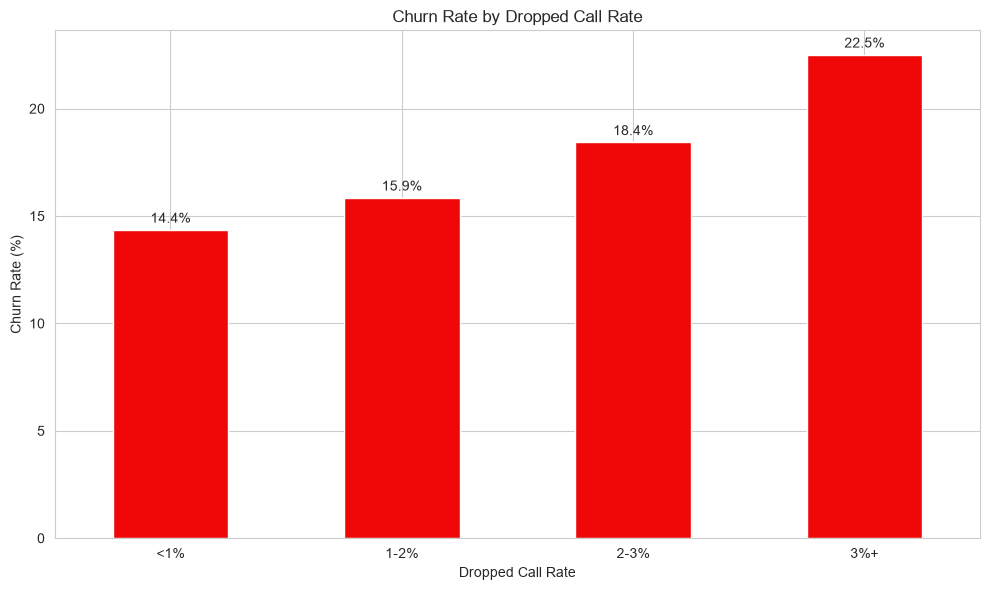

In [224]:

fig, ax = plt.subplots()
churn_by_network.plot(kind='bar', ax=ax, color="#f00808")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('Churn Rate by Dropped Call Rate')
ax.set_xlabel('Dropped Call Rate')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart9_network_quality_vs_churn.png', dpi=150)
plt.show()

Churn rate rises steadily with dropped call rate: 
customers experiencing under 1% dropped calls churn at 14.4%,
 climbing to 15.9% (1-2%), 18.4% (2-3%),
 and 22.5% for customers with a 3%+ dropped call rate
 — a roughly 1.5x increase in churn risk between the best and worst network quality bands.
 This confirms network quality is a meaningful churn driver, and suggests infrastructure investment or network optimization in high-dropped-call areas could directly reduce churn, particularly when combined with the regional findings from Chart 6 (top churn states)

In [225]:
#Chart 10: 
print(retention_campaigns.columns.tolist())

['campaign_id', 'customer_id', 'campaign_name', 'offer_type', 'contact_date', 'channel', 'response', 'retained_flag']


response
Accepted       2982
Declined       1877
No Response    1616
Name: count, dtype: int64


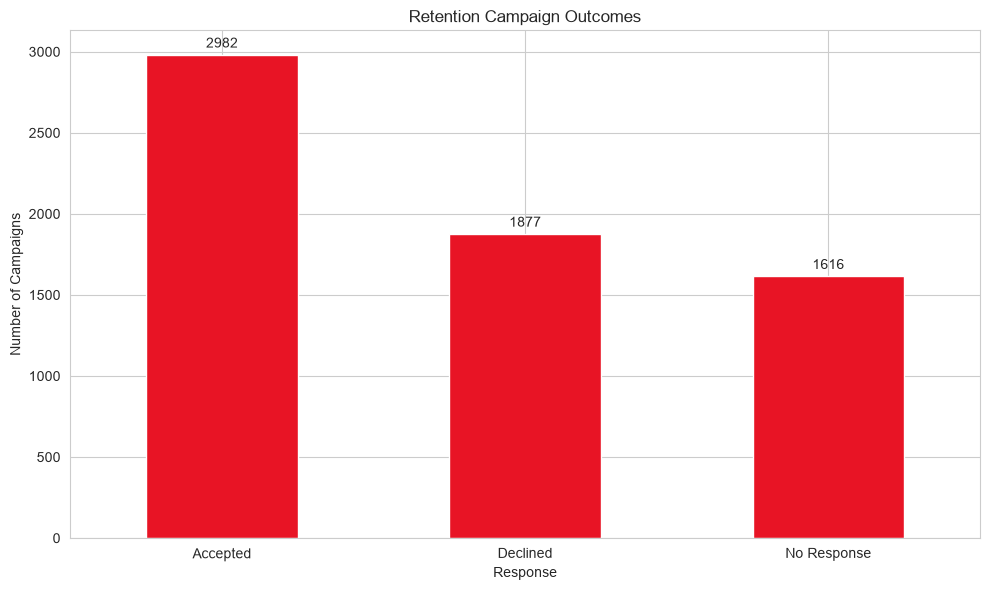

In [226]:
#
response_counts = retention_campaigns['response'].value_counts()
print(response_counts)

fig, ax = plt.subplots()
response_counts.plot(kind='bar', ax=ax, color="#e81425")

for container in ax.containers:
    ax.bar_label(container, padding=3)

ax.set_title('Retention Campaign Outcomes')
ax.set_xlabel('Response')
ax.set_ylabel('Number of Campaigns')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart10a_campaign_outcomes.png', dpi=150)
plt.show()

In [227]:
# %% Check retained_flag values
print(retention_campaigns['retained_flag'].value_counts())
print(retention_campaigns[['customer_id', 'response', 'retained_flag']].head(10))

retained_flag
Yes    5337
No     1138
Name: count, dtype: int64
  customer_id     response retained_flag
0    C0000004     Declined           Yes
1    C0000009     Declined           Yes
2    C0000015     Accepted           Yes
3    C0000016     Accepted            No
4    C0000017     Accepted            No
5    C0000022     Declined            No
6    C0000026  No Response           Yes
7    C0000028     Accepted           Yes
8    C0000037     Accepted           Yes
9    C0000038     Accepted           Yes


In [228]:
retained_share = retention_campaigns.groupby('response')['retained_flag'].apply(
    lambda x: (x == 'Yes').mean() * 100   
).sort_values(ascending=False)

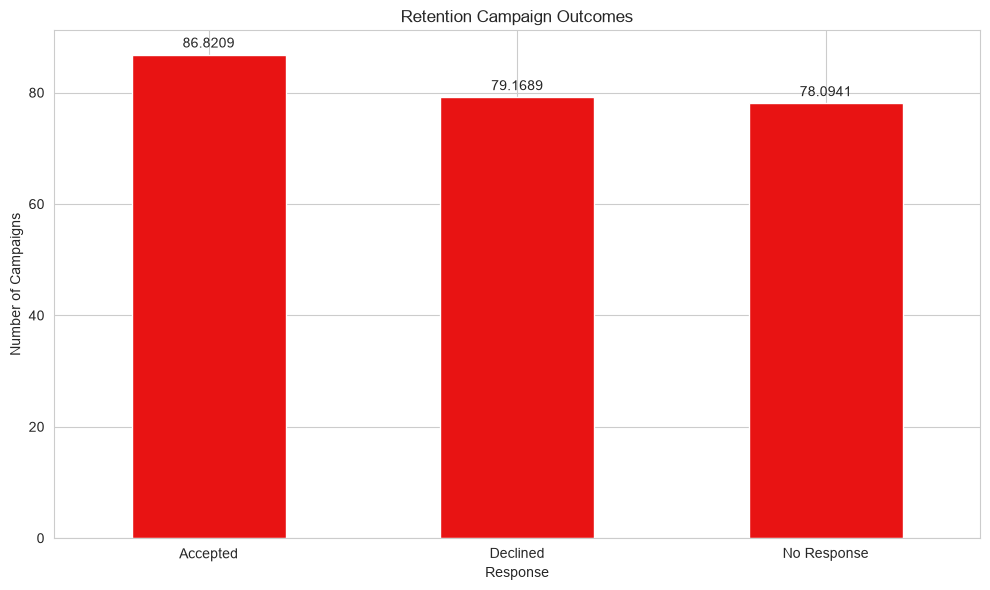

In [229]:
fig, ax = plt.subplots()
retained_share .plot(kind='bar', ax=ax, color="#e81313")

for container in ax.containers:
    ax.bar_label(container, padding=3)

ax.set_title('Retention Campaign Outcomes')
ax.set_xlabel('Response')
ax.set_ylabel('Number of Campaigns')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart10a_campaign_outcomes.png', dpi=150)
plt.show()

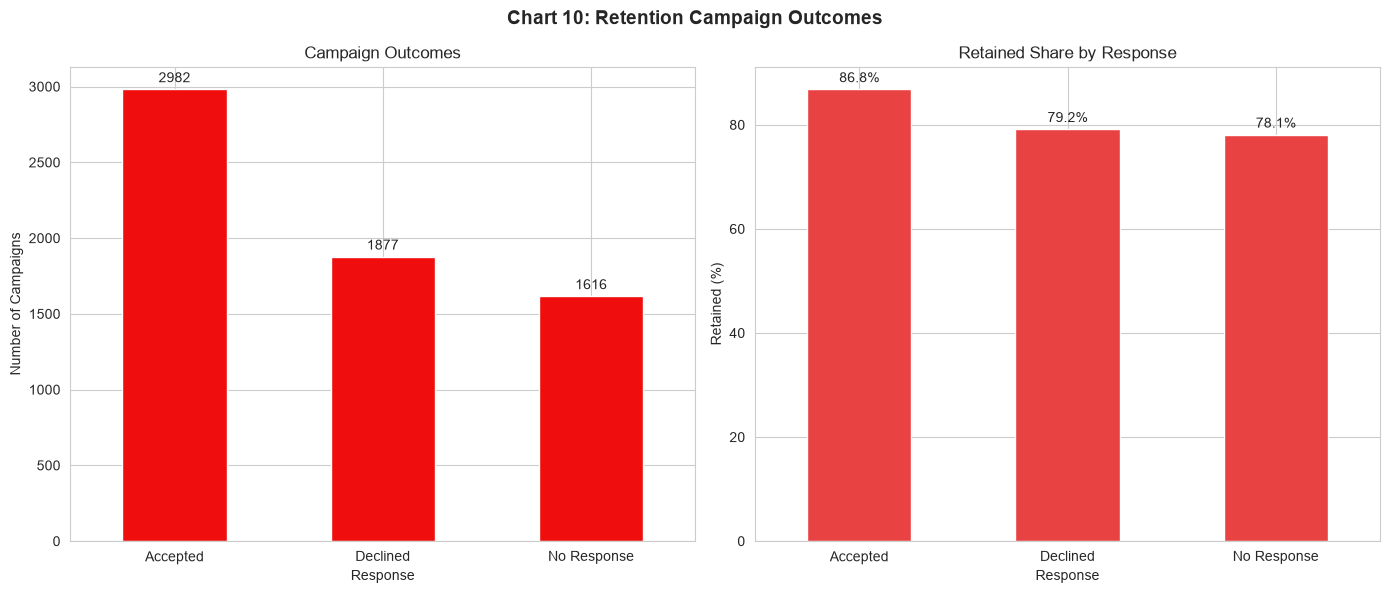

In [230]:
# Chart 10: Campaign Outcomes AND Retained Share (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: Campaign outcome counts ---
response_counts = retention_campaigns['response'].value_counts()
response_counts.plot(kind='bar', ax=axes[0], color="#ef0d0d")
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)
axes[0].set_title('Campaign Outcomes')
axes[0].set_xlabel('Response')
axes[0].set_ylabel('Number of Campaigns')
axes[0].tick_params(axis='x', rotation=0)

# --- Right panel: Retained share by response ---
retained_share = retention_campaigns.groupby('response')['retained_flag'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)
retained_share.plot(kind='bar', ax=axes[1], color="#E94242")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)
axes[1].set_title('Retained Share by Response')
axes[1].set_xlabel('Response')
axes[1].set_ylabel('Retained (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Chart 10: Retention Campaign Outcomes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_retention_campaigns.png', dpi=150)
plt.show()

Of 6,475 retention campaign contacts, 2,982 (46%) were accepted, 1,877 (29%) declined, and 1,616 (25%) had no response. 
Retained share varied meaningfully by response: 
 customers who accepted the offer were retained at 86.8%,
 compared to 79.2% for those who declined and 78.1% for no response.
 While this suggests accepting a retention offer correlates strongly with staying, it's worth noting this may partly reflect selection bias — customers already inclined to stay may be more likely to engage with and accept an offer in the first place, rather than the offer itself being the sole cause of retention.

In [231]:
#  Cleanup: remove only the genuinely superseded file
import os
if os.path.exists('chart10a_campaign_outcomes.png'):
    os.remove('chart10a_campaign_outcomes.png')
    print("Deleted chart10a_campaign_outcomes.png")

Deleted chart10a_campaign_outcomes.png


In [232]:
# %% Final check: list all chart PNGs
import os
png_files = sorted([f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')])
print(f"Found {len(png_files)} chart PNGs:")
for f in png_files:
    print(" -", f)

Found 12 chart PNGs:
 - chart10_retention_campaigns.png
 - chart1_kpi_cards.png
 - chart1_overall_churn.png
 - chart2_churn_by_billing_cycle.png
 - chart3_churn_by_tenure.png
 - chart4_churn_by_complaints.png
 - chart5_churn_by_customer_segment .png
 - chart5_churn_by_customer_segment.png
 - chart6_top10_states_by_churns.png
 - chart7_usage_by_city_tier.png
 - chart8_arpu_distribution.png
 - chart9_network_quality_vs_churn.png


In [ ]:
#  Clean up duplicate/stray chart files
import os

files_to_delete = [
    'chart5_churn_by_complaints.png',        # duplicate of chart4_churn_by_complaints.png
    'chart5_churn_by_customersegment.png',   # old draft, no underscore
]

for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found: {f}")

Not found: chart5_churn_by_complaints.png
Not found: chart5_churn_by_customersegment.png


In [234]:
# %% Final check: list all chart PNGs
png_files = sorted([f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')])
print(f"Found {len(png_files)} chart PNGs:")
for f in png_files:
    print(" -", f)

Found 12 chart PNGs:
 - chart10_retention_campaigns.png
 - chart1_kpi_cards.png
 - chart1_overall_churn.png
 - chart2_churn_by_billing_cycle.png
 - chart3_churn_by_tenure.png
 - chart4_churn_by_complaints.png
 - chart5_churn_by_customer_segment .png
 - chart5_churn_by_customer_segment.png
 - chart6_top10_states_by_churns.png
 - chart7_usage_by_city_tier.png
 - chart8_arpu_distribution.png
 - chart9_network_quality_vs_churn.png


In [235]:
# %% Delete both messy duplicate segment chart files (exact names copied from listing)
import os

files_to_delete = [
    'chart5_churn_by_customer_segment .png',   # note the space before .png
    'chart5_churn_by_customersegment .png',    # note the space before .png
]

for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found: {f}")

Deleted: chart5_churn_by_customer_segment .png
Not found: chart5_churn_by_customersegment .png


In [236]:
plt.savefig('chart5_churn_by_customer_segment.png', dpi=150)

<Figure size 1000x600 with 0 Axes>

In [237]:
# %% Final check: list all chart PNGs
png_files = sorted([f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')])
print(f"Found {len(png_files)} chart PNGs:")
for f in png_files:
    print(" -", f)

Found 11 chart PNGs:
 - chart10_retention_campaigns.png
 - chart1_kpi_cards.png
 - chart1_overall_churn.png
 - chart2_churn_by_billing_cycle.png
 - chart3_churn_by_tenure.png
 - chart4_churn_by_complaints.png
 - chart5_churn_by_customer_segment.png
 - chart6_top10_states_by_churns.png
 - chart7_usage_by_city_tier.png
 - chart8_arpu_distribution.png
 - chart9_network_quality_vs_churn.png


customer_segment
Mass          26.671214
Value         20.577792
Premium       15.126149
Enterprise    11.942446
Name: customer_status, dtype: float64


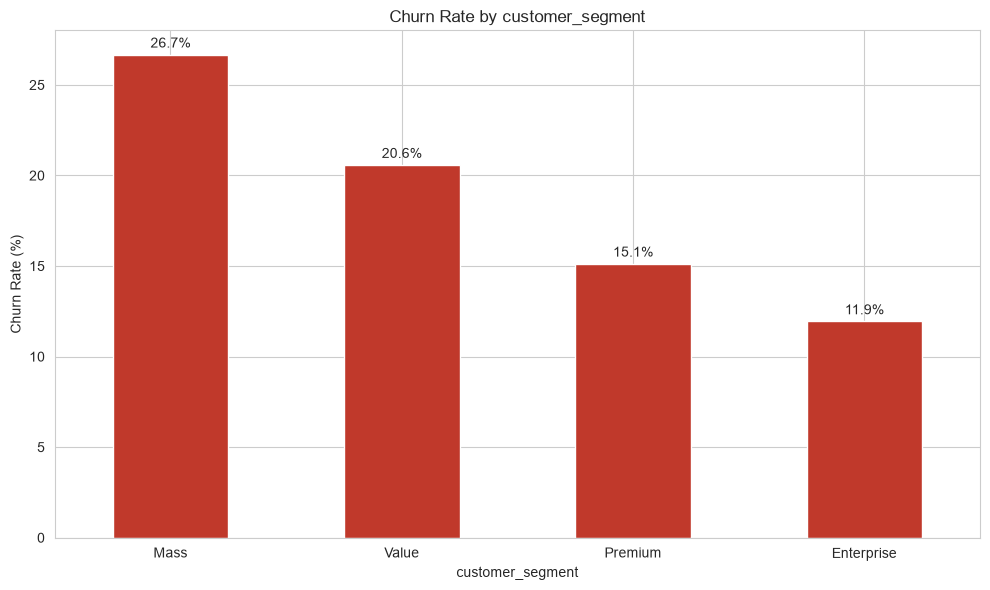

In [238]:
# %% Chart: Churn by customer segment
churn_by_customersegment = customers.groupby('customer_segment')['customer_status'].apply(
    lambda x: (x == 'Churned').mean() * 100
).sort_values(ascending=False)

print(churn_by_customersegment)

fig, ax = plt.subplots()
churn_by_customersegment.plot(kind='bar', ax=ax, color='#c0392b')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('Churn Rate by customer_segment')
ax.set_xlabel('customer_segment')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart5_churn_by_customer_segment.png', dpi=150)
plt.show()

In [239]:
plt.savefig('chart8_arpu_distribution_v2.png', dpi=150)

<Figure size 1000x600 with 0 Axes>

In [240]:
# %% Final check: list all chart PNGs
png_files = sorted([f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')])
print(f"Found {len(png_files)} chart PNGs:")
for f in png_files:
    print(" -", f)

Found 12 chart PNGs:
 - chart10_retention_campaigns.png
 - chart1_kpi_cards.png
 - chart1_overall_churn.png
 - chart2_churn_by_billing_cycle.png
 - chart3_churn_by_tenure.png
 - chart4_churn_by_complaints.png
 - chart5_churn_by_customer_segment.png
 - chart6_top10_states_by_churns.png
 - chart7_usage_by_city_tier.png
 - chart8_arpu_distribution.png
 - chart8_arpu_distribution_v2.png
 - chart9_network_quality_vs_churn.png


In [241]:
# %% Delete the leftover v2 duplicate
import os
if os.path.exists('chart8_arpu_distribution_v2.png'):
    os.remove('chart8_arpu_distribution_v2.png')
    print("Deleted chart8_arpu_distribution_v2.png")

Deleted chart8_arpu_distribution_v2.png


In [242]:
# %% Final check: list all chart PNGs
png_files = sorted([f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')])
print(f"Found {len(png_files)} chart PNGs:")
for f in png_files:
    print(" -", f)

Found 11 chart PNGs:
 - chart10_retention_campaigns.png
 - chart1_kpi_cards.png
 - chart1_overall_churn.png
 - chart2_churn_by_billing_cycle.png
 - chart3_churn_by_tenure.png
 - chart4_churn_by_complaints.png
 - chart5_churn_by_customer_segment.png
 - chart6_top10_states_by_churns.png
 - chart7_usage_by_city_tier.png
 - chart8_arpu_distribution.png
 - chart9_network_quality_vs_churn.png
